# Momentum & Value Strategy Backtester — Phase 3: Head-to-Head & Blends

This notebook puts the Phase 1 **momentum** strategy and the Phase 2 **value** strategy side by
side, then asks the natural next question: *what happens if you hold both at once?*

**Why compare them at all?** Momentum and value are classically *complementary*: momentum buys
recent winners (and tends to crash when trends reverse suddenly), value buys statistically cheap
companies (and tends to lag during long growth-led rallies). If their bad periods don't line up,
a blend can have a smoother ride than either strategy alone — that's the whole argument for
multi-factor investing, and this notebook lets us check whether it actually shows up in this data
rather than taking it on faith.

**How the blend works (and its one big convention).** Momentum produces *monthly* returns and
value produces *quarterly* returns, so the only dates where both are simultaneously observable
are quarter-ends. Momentum's monthly returns are compounded into quarterly returns (exact — no
information is invented, since quarter-ends are month-ends), and every blend below is a
**fixed-weight portfolio rebalanced back to its target split every quarter**. The alternative —
letting the split drift with performance — would mean a "50/50" portfolio quietly stops being
50/50. See `src/evaluation/comparison.py` for the full reasoning and the one cost simplification
(the small sleeve-rebalancing trades are not separately costed; each sleeve's returns are already
net of its own trading costs).

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Allow `import src.*` when this notebook is run from the notebooks/ directory.
sys.path.append(str(Path("..").resolve()))

from src.config import DEFAULT_CONFIG, DEFAULT_VALUE_CONFIG
from src.backtest.engine import run_backtest, compute_benchmark_result
from src.backtest.value_engine import run_value_backtest
from src.evaluation.comparison import (
    blend_sweep,
    combine_strategies,
    strategy_comparison_table,
)

print("Momentum config:", DEFAULT_CONFIG)
print("\nValue config:", DEFAULT_VALUE_CONFIG)

Momentum config: BacktestConfig(start_date='2012-01-01', end_date='2026-06-30', lookback_months=12, skip_months=1, rebalance_freq='ME', top_n=50, benchmark_ticker='SPY', risk_free_rate=0.0, one_way_cost_bps=10.0, price_outlier_threshold=0.5, cache_dir=WindowsPath('C:/Users/arwga/Developer/ClaudeProjects/Trading/MomentumValueStrategy/data/cache'), constituents_url='https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes%20(Updated).csv')

Value config: ValueBacktestConfig(start_date='2012-01-01', end_date='2026-06-30', rebalance_freq='QE', top_n=50, benchmark_ticker='SPY', risk_free_rate=0.0, one_way_cost_bps=10.0, price_outlier_threshold=0.5, cache_dir=WindowsPath('C:/Users/arwga/Developer/ClaudeProjects/Trading/MomentumValueStrategy/data/cache'), constituents_url='https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes%20(Updated).csv')


## 2. Run both backtests

Both runs read from the same local data cache the individual notebooks use, so this is fast once
notebooks 01/02 (or any prior run) have populated `data/cache/`. Both strategies share the same
date window, universe source, benchmark, and cost assumption by construction (see `src/config.py`),
so any difference in results below comes from the *signals*, not from incidental setup choices.

In [2]:
momentum_result = run_backtest(DEFAULT_CONFIG)
print(f"Momentum: {len(momentum_result.net_returns)} monthly returns")

value_result = run_value_backtest(DEFAULT_VALUE_CONFIG)
print(f"Value:    {len(value_result.net_returns)} quarterly returns")

$ALXN: possibly delisted; no timezone found


$ANRZQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$ANSS: possibly delisted; no timezone found


$APOL: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$ATVI: possibly delisted; no timezone found


...

$XEC: possibly delisted; no timezone found



19 Failed downloads:


['TWC', 'WFM']: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


['WBA', 'X', 'XL', 'TSS', 'WYND', 'UTX', 'WLTW', 'XLNX', 'WCG', 'VAR', 'WRK', 'VIAC', 'TWTR', 'VIAB', 'WPX', 'WIN', 'XEC']: possibly delisted; no timezone found


Value:    57 quarterly returns


In [3]:
benchmark_returns, benchmark_equity = compute_benchmark_result(DEFAULT_CONFIG)
print(f"SPY benchmark: {len(benchmark_returns)} monthly returns, "
      f"{benchmark_returns.index[0].date()} to {benchmark_returns.index[-1].date()}")

SPY benchmark: 173 monthly returns, 2012-02-29 to 2026-06-30


## 3. Side-by-side: momentum vs. value vs. SPY

Each strategy is shown at its own native frequency (monthly for momentum, quarterly for value) —
the most faithful view of each. All figures are annualized, so the columns are directly
comparable. Both strategy columns are **net of transaction costs**.

Two rows need a word of caution:
- **Avg Turnover / Rebalance** is per *rebalance event*, and the two strategies rebalance at
  different frequencies — monthly turnover of 30% is far more trading per year than quarterly
  turnover of 30%. Compare **Cost Drag** (gross CAGR minus net CAGR), which annualizes the
  consequence of that trading, rather than raw turnover.
- **CAGR vs SPY** is the headline "did it beat the index" number — but always read it next to
  volatility and max drawdown, not alone.

In [4]:
comparison = strategy_comparison_table(
    momentum_result, value_result, benchmark_returns, benchmark_equity,
    risk_free_rate=DEFAULT_CONFIG.risk_free_rate,
)
comparison.style.format("{:.2%}", na_rep="—").format(
    "{:.2f}", subset=(["Sharpe Ratio (Net)"], slice(None))
)

,Momentum (monthly),Value (quarterly),SPY Buy & Hold
CAGR (Net),15.62%,15.90%,14.50%
Annualized Volatility,16.82%,17.09%,14.06%
Sharpe Ratio (Net),0.96,0.93,1.05
Max Drawdown (Net),-19.72%,-33.76%,-23.93%
CAGR vs SPY,1.12%,1.41%,0.00%
Cost Drag (CAGR),0.78%,0.21%,—
Avg Turnover / Rebalance,28.69%,24.67%,—


## 4. The blend sweep: from 100% momentum to 100% value

Every column below is computed the same way, on the same common quarter-end dates, at the same
quarterly frequency — including the two endpoints, which are just the pure strategies re-expressed
on that common footing. (This is why the endpoint numbers can differ slightly from the table
above: same underlying returns, but measured quarterly over the common window rather than at each
strategy's native frequency over its full window.)

What to look for: if momentum and value truly diversify each other, some middle column should show
a **higher Sharpe ratio (and/or shallower max drawdown) than either endpoint** — the classic
free-lunch-from-diversification pattern. If instead the metrics just slide smoothly from one
endpoint to the other, the two strategies' good and bad periods largely overlap in this sample.

In [5]:
sweep = blend_sweep(
    momentum_result.net_returns, value_result.net_returns,
    risk_free_rate=DEFAULT_CONFIG.risk_free_rate,
)
sweep.style.format("{:.2%}").format("{:.2f}", subset=(["Sharpe Ratio"], slice(None)))

,100% Mom / 0% Val,75% Mom / 25% Val,50% Mom / 50% Val,25% Mom / 75% Val,0% Mom / 100% Val
CAGR,16.04%,16.15%,16.17%,16.09%,15.90%
Annualized Volatility,17.28%,16.40%,16.07%,16.30%,17.09%
Sharpe Ratio,0.93,0.97,0.99,0.98,0.93
Max Drawdown,-19.05%,-22.73%,-26.41%,-30.09%,-33.76%


In [6]:
# How correlated are the two strategies' quarterly returns? Low correlation is
# the mechanical reason a blend can beat both parents on risk-adjusted terms.
from src.evaluation.comparison import compound_to_quarterly

momentum_quarterly = compound_to_quarterly(momentum_result.net_returns)
common = momentum_quarterly.index.intersection(value_result.net_returns.index)
correlation = momentum_quarterly.loc[common].corr(value_result.net_returns.loc[common])
print(f"Correlation of quarterly net returns (momentum vs value): {correlation:.2f}")

Correlation of quarterly net returns (momentum vs value): 0.75


## 5. Equity curves across the sweep

Growth of $1 for each split, on the common quarterly window (log scale, same reasoning as the
other notebooks: over ~14 years a linear scale squashes the early years flat).

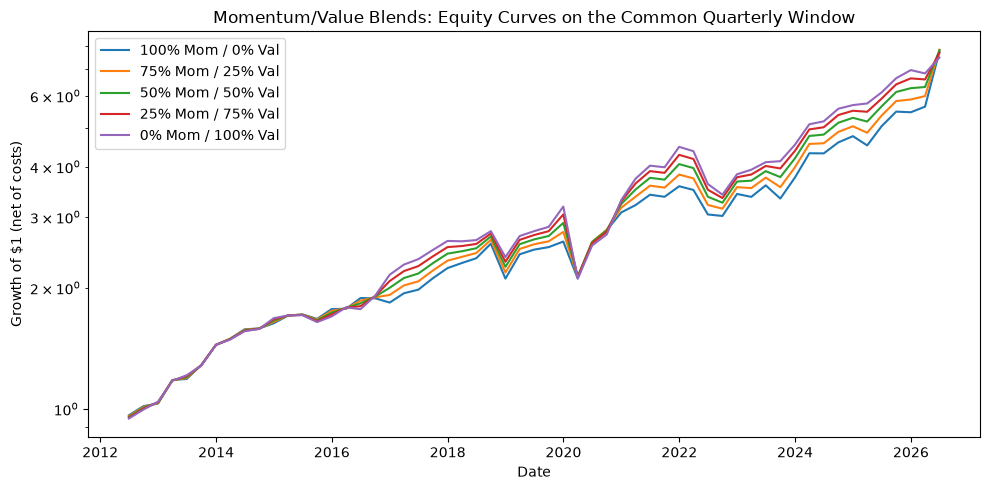

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for w in [1.0, 0.75, 0.5, 0.25, 0.0]:
    blend = combine_strategies(momentum_result.net_returns, value_result.net_returns, w)
    ax.plot(blend.equity.index, blend.equity, label=f"{w:.0%} Mom / {1-w:.0%} Val")
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 (net of costs)")
ax.set_title("Momentum/Value Blends: Equity Curves on the Common Quarterly Window")
ax.legend()
fig.tight_layout()

## 6. Try your own split

Change `momentum_weight` below to any value between 0 and 1 and re-run the cell — e.g. `0.6`
means 60% momentum / 40% value. You get the full metric set and a plottable equity curve back.

60% momentum / 40% value:

CAGR                     0.1618
Annualized Volatility    0.1613
Sharpe Ratio             0.9902
Max Drawdown            -0.2494


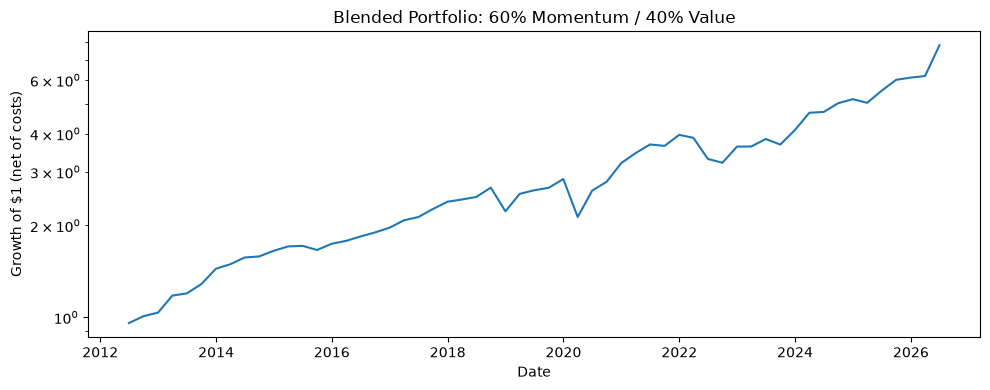

In [8]:
momentum_weight = 0.6  # <-- edit me (fraction in momentum; the rest goes to value)

blend = combine_strategies(
    momentum_result.net_returns, value_result.net_returns, momentum_weight,
    risk_free_rate=DEFAULT_CONFIG.risk_free_rate,
)
print(f"{momentum_weight:.0%} momentum / {1-momentum_weight:.0%} value:\n")
print(blend.metrics.to_string(float_format=lambda x: f"{x:,.4f}"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(blend.equity.index, blend.equity)
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 (net of costs)")
ax.set_title(f"Blended Portfolio: {momentum_weight:.0%} Momentum / {1-momentum_weight:.0%} Value")
fig.tight_layout()

## 7. Limitations

- **The blend is evaluated quarterly, on the common window only.** Momentum's monthly detail is
  compounded away (exactly, but volatility measured from 57-ish quarterly observations is a
  noisier estimate than from 170-ish monthly ones), and any early months before the value
  strategy's first quarter are dropped from the blend.
- **Sleeve-rebalancing trades aren't separately costed.** Pulling the two sleeves back to target
  weight each quarter trades a few percent of portfolio value; at the 10bps one-way assumption
  that's roughly a basis point per quarter of drag the blend numbers don't include. The pure
  100/0 and 0/100 columns are unaffected.
- **Both parents' own limitations carry through** — see the Limitations sections of notebooks 01
  (price/universe caveats) and 02 (fundamentals coverage and tagging caveats). In particular, the
  value sleeve's universe is effectively the ~76% of point-in-time constituents with SEC
  fundamentals coverage.
- **One shared 14-year sample.** A blend that looks best at, say, 50/50 in this window is not a
  promise about the next 14 years — the honest claim is about the *pattern* (diversification
  between the two signals), not the precise optimal weight.

> **Phase 5 update:** the "one shared 14-year sample" caveat above was later tested directly.
> A walk-forward test (choose the best-looking blend weight from trailing data only, apply it to
> the next unseen year) found the chosen weight is unstable and that adapting it *underperforms*
> every fixed weight — and out-of-sample, fixed 50/50 is roughly tied with pure momentum rather
> than clearly best. The diversification pattern is real; the precise "50/50 is best" reading of
> the table above was partly a full-sample artifact. See notebook 05 and REVIEW_PHASE5.md §6.

## 8. Conclusion

This notebook adds the head-to-head comparison and fixed-weight blending layer on top of the two
strategy backtests, computed from the same engines, metrics, and cost assumptions as the
individual notebooks — so every number here is consistent, by construction, with what notebooks
01 and 02 report.